# Logistic regression

assumptions:
1. linearity

2. independence observation
- this means that P(A&B) = P(A) * P(B)

3. little to no multicore ​linearity between the independent variables. ​

4. assuming no extreme outliers (need to deal with after fitting the model)


### linearity assumption:

- the linearity assumption states that there ​should be a linear relationship between each X variable and ​the logit of the probability that Y equals 1


lets say the probability of an event is `P`

then the `"logic"` or `log odds` of the event is equal to 

`log ((p-1)/p)` = b0 + b1x1 + b2x2 + .... + bnxn



<br>
unlike linear regression, we use `Maximum likelihood estimation` for logistic regression
= estimating the beta parameters that maximize the likelihood of a model producing the observed data.


<br><br>

-------------------------------------------------------------------------



In [93]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
import math

# 1. Create a dummy dataset of 100 filter samples
np.random.seed(42)
# Generate random Levoglucosan concentrations from 0 to 150 ng/m3
levo_concentration = np.random.uniform(0, 150, 100)

# lets say we add an not so important temperature column...
temp = np.random.uniform(22, 27, 100)

# True underlying rule: if Levo > 60 ng/m3, it's highly likely a smoke event
# We add randomness to simulate real atmospheric mixing and varying wind directions
prob_smoke = 1 / (1 + np.exp(-(levo_concentration - 60) / 12))
smoke_impacted = np.where(np.random.uniform(0, 1, 100) < prob_smoke, 1, 0)

# Build the clean DataFrame
df_air = pd.DataFrame({
    'Levoglucosan_ng_m3': levo_concentration,
    'Smoke_Impacted': smoke_impacted,
    "Temperature": temp
})

print(df_air.head(10))

   Levoglucosan_ng_m3  Smoke_Impacted  Temperature
0           56.181018               0    22.157146
1          142.607146               1    25.182052
2          109.799091               1    23.571780
3           89.798773               1    24.542853
4           23.402796               0    26.537832
5           23.399178               1    23.246461
6            8.712542               0    24.051915
7          129.926422               1    25.777756
8           90.167252               1    23.143991
9          106.210887               1    22.384900


in python, we can use `from sklearn.linear_model.LogisticRegression()`

if can read more about it here : https://scikit-learn.org/stable/modules/generated/sklearn.linear_model.LogisticRegression.html

p.s. 
if you want, use `sklearn.model_selection.train_test_split` for reserving some testing data later

In [94]:
## lets hold some data (1/4) for testing 
X = df_air[['Levoglucosan_ng_m3']]
y = df_air['Smoke_Impacted']

X_air, X_test, y_air, y_test = train_test_split(X, y, test_size=0.25, random_state=42)


C:\Users\wayne\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LogisticRegression was fitted with feature names
  warnings.warn(


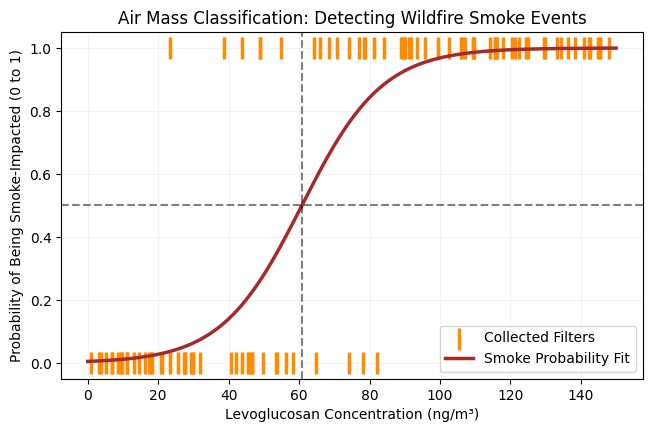

The 50% classification threshold is at: 60.80 ng/m³


In [95]:

# 2. Fit the Logistic Regression Model

air_model = LogisticRegression()
air_model.fit(X_air, y_air)

# 3. Generate a smooth concentration scale for plotting the curve
X_smooth_air = np.linspace(0, 150, 300).reshape(-1, 1)
predicted_probs_air = air_model.predict_proba(X_smooth_air)[:, 1]

# 4. Plot the results
plt.figure(figsize=(7.5, 4.5))

# Plot the real filter samples as discrete dashes at 0 and 1
plt.scatter(df_air['Levoglucosan_ng_m3'], df_air['Smoke_Impacted'], 
            color='darkorange', marker='|', s=250, linewidths=2.5, label='Collected Filters')

# Plot the fitted Sigmoidal S-Curve
plt.plot(X_smooth_air, predicted_probs_air, color='brown', linewidth=2.5, label='Smoke Probability Fit')

# Calculate and draw the 50% classification threshold
threshold_concentration = -air_model.intercept_[0] / air_model.coef_[0][0]
plt.axvline(x=threshold_concentration, color='black', linestyle='--', alpha=0.5)
plt.axhline(y=0.5, color='black', linestyle='--', alpha=0.5)

plt.title('Air Mass Classification: Detecting Wildfire Smoke Events')
plt.xlabel('Levoglucosan Concentration (ng/m³)')
plt.ylabel('Probability of Being Smoke-Impacted (0 to 1)')
plt.grid(True, alpha=0.15)
plt.legend(loc='lower right')
plt.show()

print(f"The 50% classification threshold is at: {threshold_concentration:.2f} ng/m³")

In [96]:
y_pred = air_model.predict(X_test)
y_pred

array([0, 1, 1, 1, 0, 1, 0, 1, 0, 0, 1, 1, 1, 1, 0, 0, 1, 0, 1, 0, 1, 1,
       0, 0, 1])

In [97]:
air_model.predict_proba(X_test)[::,-1]

array([0.01123027, 0.99836319, 0.99189634, 0.96674492, 0.12785366,
       0.61212579, 0.1849853 , 0.99752176, 0.00642643, 0.40049784,
       0.58630789, 0.93397508, 0.99538365, 0.99919321, 0.02311988,
       0.03674056, 0.99179307, 0.01286295, 0.99630108, 0.04409164,
       0.99885102, 0.99819178, 0.06330014, 0.00769065, 0.99950947])

The upper-left quadrant displays the number of true negatives = TN 

The bottom-left quadrant displays the number of false negatives =FN

The upper-right quadrant displays the number of false positives = FP

The bottom-right quadrant displays the number of true positives = TP

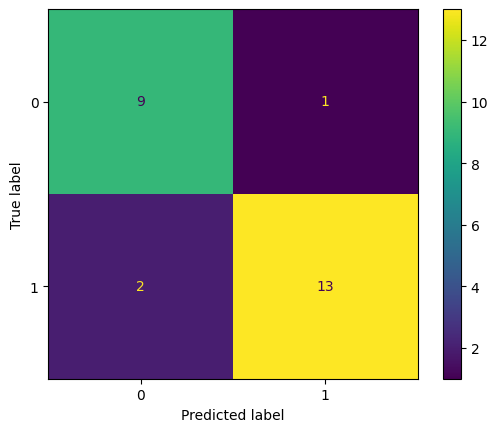

In [98]:
import sklearn.metrics as metrics

cm = metrics.confusion_matrix(y_test, y_pred, labels = air_model.classes_)
disp = metrics.ConfusionMatrixDisplay(confusion_matrix = cm,display_labels = air_model.classes_)
disp.plot()

and note that in this kind of modeling

Accuracy = (TP+TN) / total
- this means how many are accurately classified
- note that accuracy is more appropriate when TP and TN are roughly equal in the data. e.g., accuracy of 95% sounds nice but it's bias and not really reflecting the performance when only 1% of the population has an disease.

Precision = TP/(TP+FP)
- How many predicted positives were actually correct
- this is helpful when the cost of a false positive is quite high and cost of FP > FP
- e.g., falsely detect manuascript acceptance email as spam


Recall = TP / (TP + FN)
- Recall measures the proportion of data points that are predicted as True, out of all the data points that are actually True (False negative is actually True...)
- This is helpful if we care about false negative and cost of FN > FP 
- e.g., falsly detect non-emergency event

In [99]:
accuracy = metrics.accuracy_score(y_test, y_pred)
precision = metrics.precision_score(y_test, y_pred)
recall = metrics.recall_score(y_test, y_pred)

print("accuracy: ", accuracy)
print("precision: ", precision)
print("recall: ", recall)

#-------- or we can do the math -------------
print("---------------------")
[tn, fp], [fn, tp] = cm
total = tn + fp + fn + tp
accuracy = (tp+tn) / total
precision=  tp/(tp+fp)
recall = tp / (tp + fn)
print("accuracy: ", accuracy)
print("precision: ", precision)
print("recall: ", recall)


accuracy:  0.88
precision:  0.9285714285714286
recall:  0.8666666666666667
---------------------
accuracy:  0.88
precision:  0.9285714285714286
recall:  0.8666666666666667


## ROC curves

For each point on the curve, the x and y coordinates represent the False Positive Rate and the True Positive Rate respectively at the corresponding threshold.

In the ROC curve for an ideal model, there would exist a threshold at which the True Positive Rate is high and the False Positive Rate is low. The more that the ROC curve hugs the top left corner of the plot, the better the model does at classifying the data.

and usually we add a 1:1 line, this means a random guess result (1 or 0)

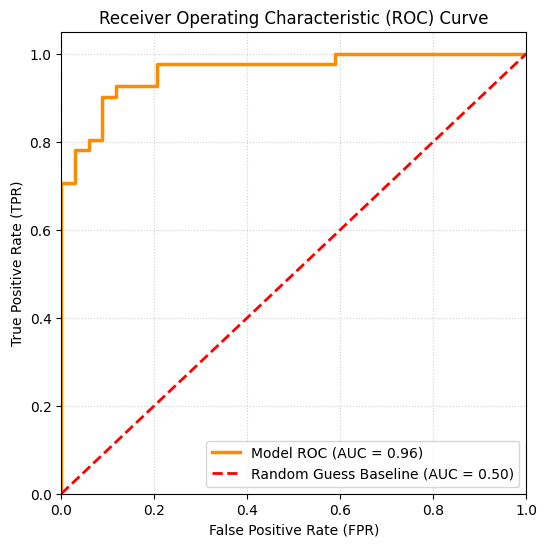

In [ ]:
from sklearn.metrics import roc_curve, roc_auc_score

# 1. Calculate the predicted probabilities for the real data
# air_model was trained in the previous step; we extract the probability for class 1 (Smoke)
# note that predict_proba returns two arrays: the probability of 0 (not smoke) and probability of 1 (smoke)
# each number for a sample simply means the probability of the sample is (not smoke) or 1 (smoke)
y_probs = air_model.predict_proba(X_air)[:, 1]

# 2. Compute the FPR, TPR, and thresholds using scikit-learn
fpr, tpr, thresholds = roc_curve(y_air, y_probs)

# 3. Calculate the exact AUC score
auc_score = roc_auc_score(y_air, y_probs)

# 4. Plotting the ROC Curve
plt.figure(figsize=(6, 6)) # A square figure is standard for ROC curves
plt.plot(fpr, tpr, color='darkorange', lw=2.5, label=f'Model ROC (AUC = {auc_score:.2f})')

# --- VISUALIZING THE 0.5 AUC LINE ---
# We use plt.plot() to draw a straight line from (0,0) to (1,1)
# 'r--' makes it red and dashed to denote it as a baseline reference
plt.plot([0, 1], [0, 1], color='red', lw=2, linestyle='--', label='Random Guess Baseline (AUC = 0.50)')

# Formatting the plot
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05]) # Slightly higher than 1.0 so the top boundary isn't cut off
plt.xlabel('False Positive Rate (FPR)')
plt.ylabel('True Positive Rate (TPR)')
plt.title('Receiver Operating Characteristic (ROC) Curve')
plt.legend(loc="lower right")
plt.grid(True, linestyle=':', alpha=0.6)

plt.show()

or we can let the pacakge handle the calculation and plot... 

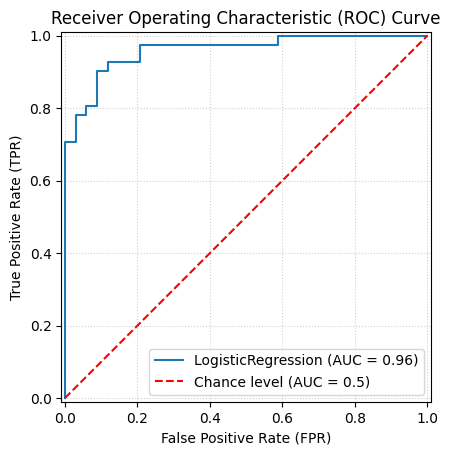

In [101]:
from sklearn.metrics import RocCurveDisplay


RocCurveDisplay.from_estimator(air_model, X_air, y_air,
                                 plot_chance_level=True, 
                                 chance_level_kw= {"color":"r"}
                                 )
plt.xlabel('False Positive Rate (FPR)')
plt.ylabel('True Positive Rate (TPR)')
plt.title('Receiver Operating Characteristic (ROC) Curve')
plt.legend(loc="lower right")
plt.grid(True, linestyle=':', alpha=0.6)

plt.show()



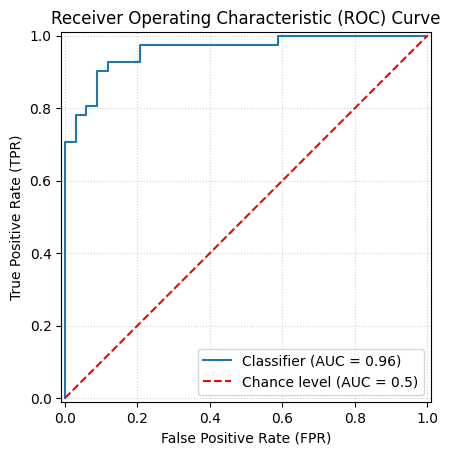

In [102]:
# or we can directly plot by the prediction results
RocCurveDisplay.from_predictions(y_air, y_probs, 
                                 plot_chance_level=True, 
                                 chance_level_kw= {"color":"r"}
                                 )
plt.xlabel('False Positive Rate (FPR)')
plt.ylabel('True Positive Rate (TPR)')
plt.title('Receiver Operating Characteristic (ROC) Curve')
plt.legend(loc="lower right")
plt.grid(True, linestyle=':', alpha=0.6)

plt.show()

now we can go back into the model itself. 

recall that `logic(p) = log ((p-1)/p) = b1x1 + b2x2 + .... + bnxn `

now since we only have one variable, there's only `b1x1` in the equation. 

from `air_model.coef_`, we can get the `b1` coefficient



In [103]:
b1 = air_model.coef_[0][0]

print(f"This means a one-unit increase in the variable `x1` is associated with a {b1} increase in the log odds of p")
# in odds of Y as a percentage, you can exponentiate b1
r = np.exp(b1)
print(f"this will translate into every unit increase in x1 variable, there's {r} increase in Y")
r_pct = (r - 1) * 100
print(f"or {r_pct} % increase in Y")

This means a one-unit increase in the variable `x1` is associated with a 0.08734611428375479 increase in the log odds of p
this will translate into every unit increase in x1 variable, there's 1.0912743199908053 increase in Y
or 9.127431999080526 % increase in Y


 of course we always care about p-value. 

so far we have been using `sklearn` but this is more of modeling package and not for stats. to get p-value, we need to go back to statsmodel.

but wait we need to add an extra column.

recall that our model is  `y = log ((p-1)/p) = b0 + b1x1 + b2x2 + .... + bnxn`

where `b0` is the y-intercepte, which means it's the baseline or y value when all x values are 0. in our case, when the Levoglucosan_ng_m3== 0 and temperature == 0. this is currently missing in our data (this is literally just 1 for the entire column since there's no x term for b0).

but why we need to add this? doesnt the model consider it?

since sklearn is more optimized for modeling, it automatically creates and calculates the intercept (b0) behind the scenes unless you explicitly tell it not to (with using argument `fit_intercept=False`).

however, since we're using `statsmodels`, which does not assume you want an intercept. If you feed it a matrix containing just your raw data columns, it will only solve for b1 and b2. This is bad and will ruin the model calculation. 

so... we need to add an extra column in this case to prevent that by using `add_constant()`

In [113]:
import statsmodels.api as sm
X_stats = sm.add_constant(df_air['Levoglucosan_ng_m3'])
y_stats = df_air['Smoke_Impacted']


# 2. Fit the Logit model
logit_model = sm.Logit(y_stats, X_stats).fit()

# 3. Print the comprehensive statistical summary table
print(logit_model.summary())

Optimization terminated successfully.
         Current function value: 0.250005
         Iterations 8
                           Logit Regression Results                           
Dep. Variable:         Smoke_Impacted   No. Observations:                  100
Model:                          Logit   Df Residuals:                       98
Method:                           MLE   Df Model:                            1
Date:                Wed, 17 Jun 2026   Pseudo R-squ.:                  0.6355
Time:                        16:27:36   Log-Likelihood:                -25.000
converged:                       True   LL-Null:                       -68.593
Covariance Type:            nonrobust   LLR p-value:                 9.883e-21
                         coef    std err          z      P>|z|      [0.025      0.975]
--------------------------------------------------------------------------------------
const                 -4.8953      1.024     -4.779      0.000      -6.903      -2.888
Levog

In [ ]:
# or we can make it a multivariate model, it's mostly the same but just add Temperature into the model
X_multi = df_air[['Levoglucosan_ng_m3', 'Temperature']]
X_multi = sm.add_constant(X_multi)
y_air = df_air['Smoke_Impacted']

multi_logit_model = sm.Logit(y_air, X_multi).fit()
print(multi_logit_model.summary())

this output a few things we might want to check:

`converged`: if this is false, the Maximum Likelihood Estimation (MLe which is Method used) is not successful for the curve fitting which means the data is too chaotic or messy to fit.

`Pseudo R-squ`: the logistic regression equivalent of the standard linear R^2 value.

`LLR p-value`: p-value for the entire model overall

in the second part:

`coef` present the bn from b0 b1 for (Levoglucosan_ng_m3) to b2 (Temperature)

`P>|z|`: this is the p-value we want tknow know. we have 0.000 for Levoglucosan_ng_m3, and 0.924 for Temperature, meaning that the Temperature to result is 92.4% random and not valid!

`[0.025      0.975]`: this is the 95% Confidence Intervals. narrower = better